In [1]:
pip install ucimlrepo


Note: you may need to restart the kernel to use updated packages.


In [56]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
chronic_kidney_disease = fetch_ucirepo(id=336) 
  
# data (as pandas dataframes) 
X = chronic_kidney_disease.data.features 
y = chronic_kidney_disease.data.targets 
  
# metadata 
print(chronic_kidney_disease.metadata) 
  
# variable information 
print(chronic_kidney_disease.variables) 


{'uci_id': 336, 'name': 'Chronic Kidney Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/336/data.csv', 'abstract': 'This dataset can be used to predict the chronic kidney disease and it can be collected from the hospital nearly 2 months of period.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 400, 'num_features': 24, 'feature_types': ['Real'], 'demographics': ['Age'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Mar 04 2024', 'dataset_doi': '10.24432/C5G020', 'creators': ['L. Rubini', 'P. Soundarapandian', 'P. Eswaran'], 'intro_paper': None, 'additional_info': {'summary': 'We use the following representation to collect the dataset\r\n                        age\t\t-\tage\t\r\n\t\t\tbp\t\t-\tblood pressure\r\n\t\t\tsg\t

In [57]:
import pandas as pd

#Combine into one DataFrame
df = pd.concat([X, y], axis=1)
df.head()


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [58]:
# Keep only the columns required
df = df[['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sod',
         'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'class']]

df.head()

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,15.4,44.0,7800.0,5.2,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,NaN,NaN,11.3,38.0,6000.0,NaN,ckd
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,NaN,NaN,9.6,31.0,7500.0,NaN,ckd
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,11.2,32.0,6700.0,3.9,ckd
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,11.6,35.0,7300.0,4.6,ckd


In [59]:
# Convert hemoglobin from g/dl to g/l
df['hemo'] = df['hemo'] * 10

df.head()


,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,NaN,NaN,154.0,44.0,7800.0,5.2,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,NaN,NaN,113.0,38.0,6000.0,NaN,ckd
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,NaN,NaN,96.0,31.0,7500.0,NaN,ckd
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,111.0,2.5,112.0,32.0,6700.0,3.9,ckd
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,NaN,NaN,116.0,35.0,7300.0,4.6,ckd


In [61]:
# Clean class labels: ckd to c, notckd to a
df['class'] = df['class'].replace({
    'ckd': 'a',
    'ckd\t': 'a',
    'notckd': 'c'
})

In [62]:
# Check unique class values
df['class'].unique()

<ArrowStringArray>
['a', 'c']
Length: 2, dtype: str

In [63]:
# Count missing values per row
missing_per_row = df.isna().sum(axis=1)
missing_per_row.head()


0    2
1    4
2    3
3    0
4    2
dtype: int64

In [64]:
# Remove rows with 3 or more missing values
df_clean = df[missing_per_row < 3].copy()


In [65]:
print("rows in original:", len(df))
print("rows after cleaning:", len(df_clean))


rows in original: 400
rows after cleaning: 265


In [66]:
# Split into affected (a) and control (c) groups
df_c = df_clean[df_clean['class'] == 'c']
df_a = df_clean[df_clean['class'] == 'a']


In [67]:
print("Affected:", len(df_a))
print("Control:", len(df_c))


Affected: 126
Control: 139


In [68]:
# Summary statistics for both groups
df_c.describe(include='all')
df_a.describe(include='all')


,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
count,123.000000,125.000000,125.000000,126.000000,126.000000,120.000000,125.000000,108.000000,108.000000,125.000000,125.000000,113.000000,108.000000,126
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126
mean,57.081301,80.720000,1.013560,1.849206,0.809524,181.200000,80.420000,133.731481,4.751852,106.432000,32.440000,9450.442478,3.976852,NaN
std,14.465104,15.769305,0.004527,1.437038,1.366539,93.549394,60.501346,7.666661,4.203592,21.896507,7.150908,3720.458015,0.844510,NaN
min,6.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,104.000000,2.500000,31.000000,9.000000,2600.000000,2.100000,NaN
25%,49.500000,70.000000,1.010000,0.250000,0.000000,107.000000,37.000000,131.750000,3.800000,95.000000,29.000000,7100.000000,3.400000,NaN
50%,60.000000,80.000000,1.015000,2.000000,0.000000,158.000000,60.000000,136.000000,4.200000,108.000000,33.000000,9200.000000,3.900000,NaN
75%,65.000000,90.000000,1.015000,3.000000,1.000000,241.250000,107.000000,139.000000,4.900000,120.000000,37.000000,11000.000000,4.400000,NaN


In [69]:
import matplotlib.pyplot as plt

# Function to plot histograms for all numeric columns
def plot_ckd(df):
    plt.figure(figsize=(20, 10))
    for i, col in enumerate(df.select_dtypes(include=['int', 'float'])):
        plt.subplot(4, 4, i + 1)
        df[col].plot(kind='hist', title=col)
        plt.xlabel(col)
    


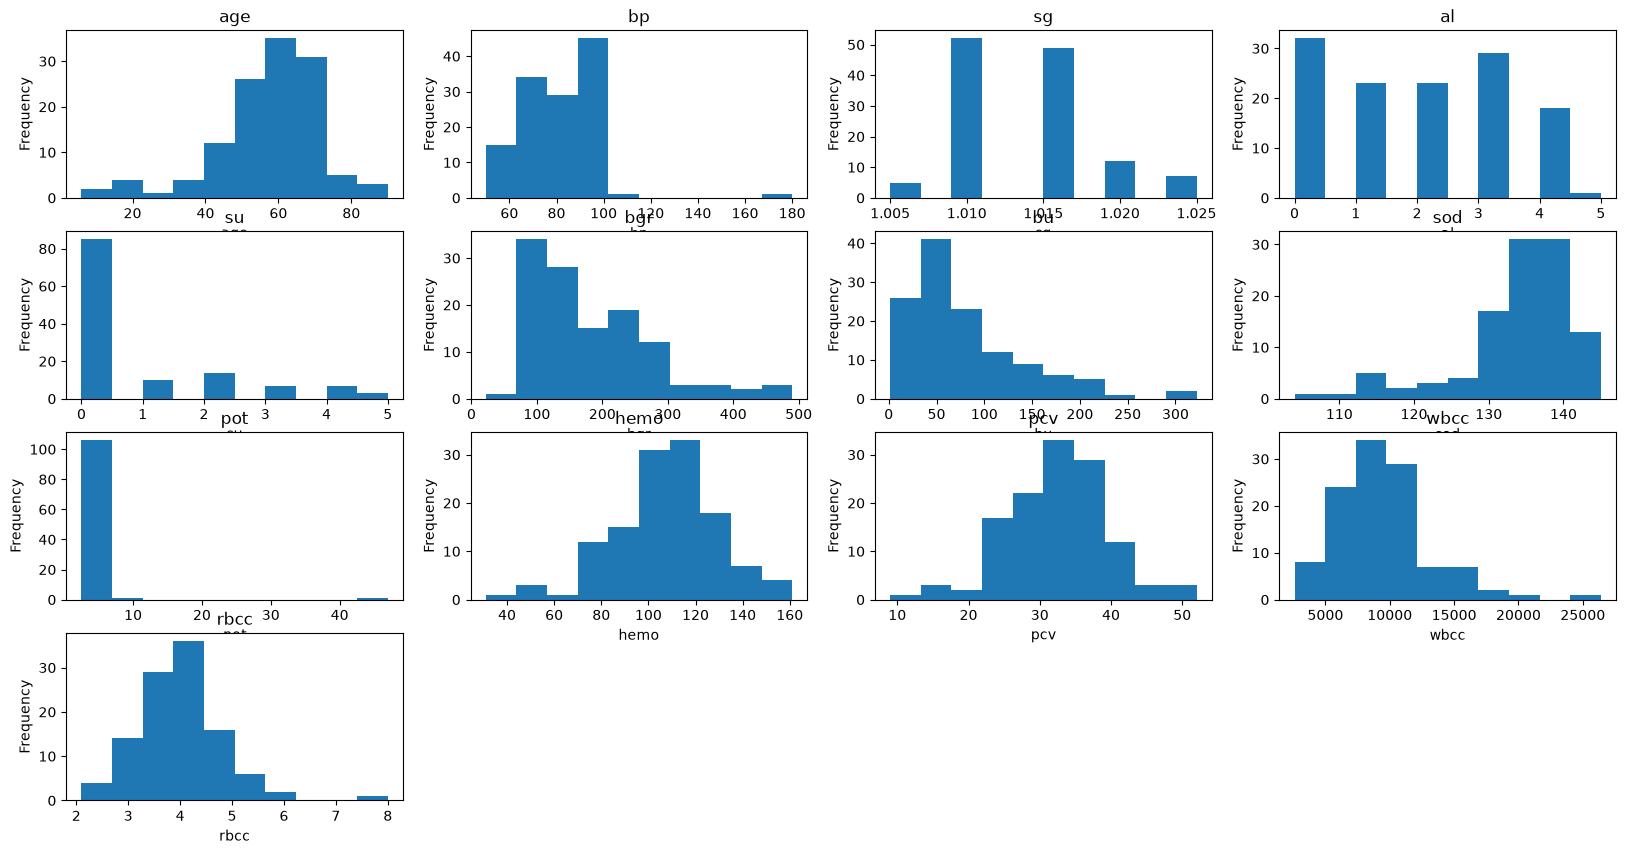

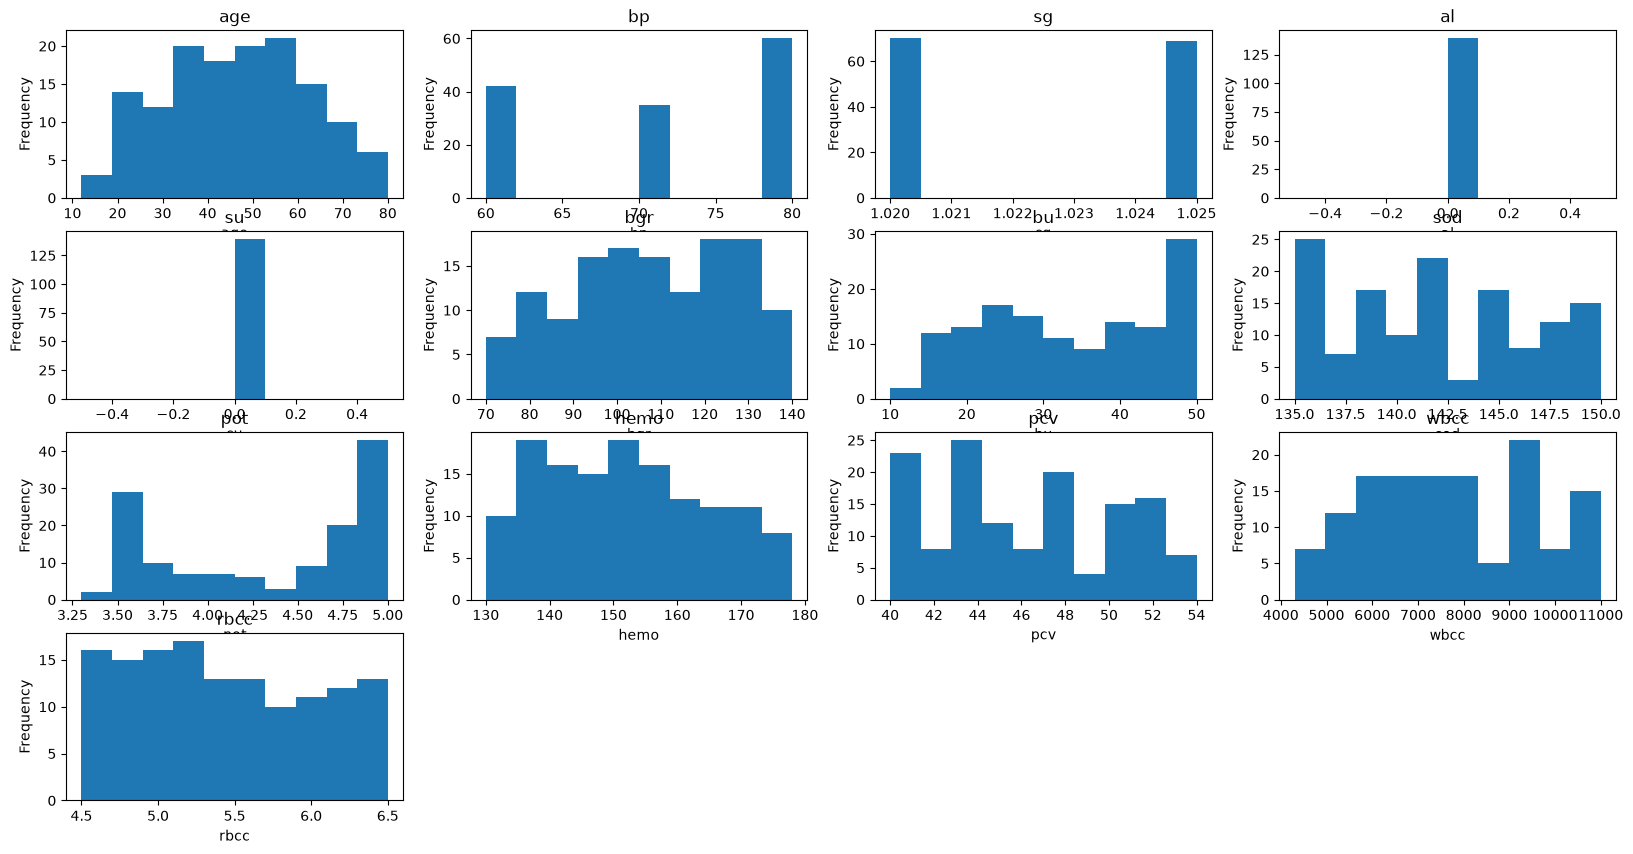

In [70]:
# Plot histograms for affected and control groups
plot_ckd(df_a)
plot_ckd(df_c)



In [ ]:
#Most variables look fine, but I see extreme values in urea, potassium, and blood pressure.
#I would handle them by droping physiologically impossible rows


In [71]:
# Correlation matrices (drop class because it's not numeric)
corr_c = df_c.drop(columns=['class']).corr()
corr_c

corr_a = df_a.drop(columns=['class']).corr()
corr_a



,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc
age,1.000000,0.061731,-0.004869,-0.016726,0.138945,0.205133,0.022593,-0.033951,-0.007490,-0.006174,-0.044467,0.015848,-0.016616
bp,0.061731,1.000000,0.066651,0.022210,0.181615,0.041162,0.064547,0.148208,0.068721,-0.097107,-0.104029,-0.040061,0.095163
sg,-0.004869,0.066651,1.000000,-0.061509,-0.044993,-0.083967,-0.037977,0.143235,0.046375,0.114042,0.106808,-0.026688,0.120779
al,-0.016726,0.022210,-0.061509,1.000000,0.115618,0.099096,0.426974,-0.179331,0.176842,-0.371257,-0.329337,0.067898,-0.231920
su,0.138945,0.181615,-0.044993,0.115618,1.000000,0.692159,-0.053597,0.052022,0.152143,0.184927,0.120275,0.103631,0.091519
bgr,0.205133,0.041162,-0.083967,0.099096,0.692159,1.000000,-0.029130,-0.053968,0.019949,0.144666,0.097501,0.049505,0.140348
bu,0.022593,0.064547,-0.037977,0.426974,-0.053597,-0.029130,1.000000,-0.320019,0.197928,-0.608652,-0.568745,-0.135999,-0.487755
sod,-0.033951,0.148208,0.143235,-0.179331,0.052022,-0.053968,-0.320019,1.000000,0.002814,0.295139,0.317933,0.019716,0.266934
pot,-0.007490,0.068721,0.046375,0.176842,0.152143,0.019949,0.197928,0.002814,1.000000,-0.181083,-0.198267,-0.169084,-0.185432
hemo,-0.006174,-0.097107,0.114042,-0.371257,0.184927,0.144666,-0.608652,0.295139,-0.181083,1.000000,0.951500,0.071613,0.779202


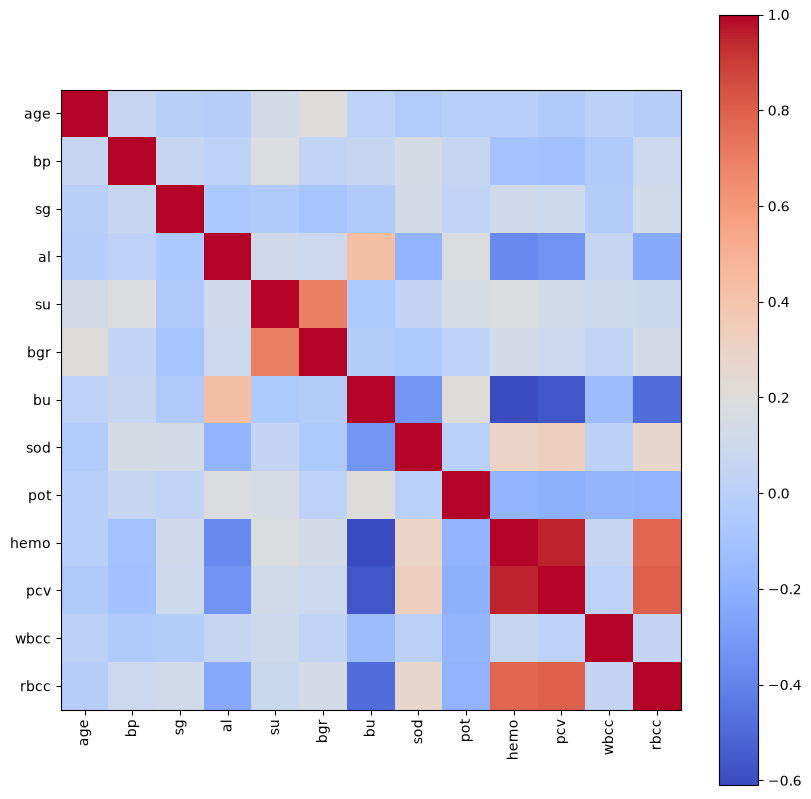

In [72]:
# Heatmap for groups
plt.figure(figsize=(10, 10))
plt.imshow(corr_a, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr_a)), corr_a.columns, rotation=90)
plt.yticks(range(len(corr_a)), corr_a.columns)
plt.show()


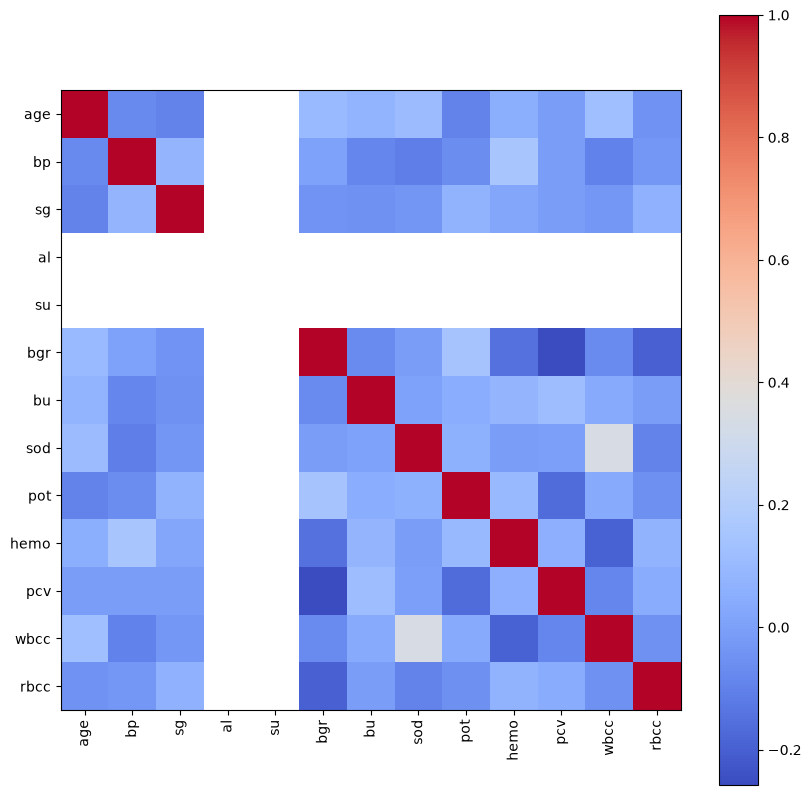

In [73]:
plt.figure(figsize=(10, 10))
plt.imshow(corr_c, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr_c)), corr_c.columns, rotation=90)
plt.yticks(range(len(corr_c)), corr_c.columns)
plt.show()


In [ ]:
#Control samples show no albumin or sugar in urine (no variance), while the affected group has abnormalities. Hemoglobin, packed cell volume and 
#RBC are strongly correlated with each other in the affected group. Packed cell volume and RBC correlate negatively with blood urea, and albumin 
#in urine shows a relationship with blood urea. Urine sugar correlates with blood glucose. Overall, the control group looks normal; the affected group shows patterns consistent with
#kidney dysfunction and related anemia.